# 32-Channel EEG Simulation (Piecewise-Stationary Windows)

This notebook simulates **32 electrodes** at **fs=1000 Hz** using `SL_GPsim` with **piecewise-stationary 5-second windows**.

## Scenario (propofol-like trajectory)
- **0-2 min (awake, eyes closed):** frontal alpha present; posterior has ~no rhythms.
- **2-4 min (induction/propofol):** posterior alpha + slow wave ramp up; broadband slope exponent steepens.
- **4-6 min (emergence):** posterior rhythms ramp down; slope returns to baseline; frontal returns to baseline eyes-closed alpha.

We save the full 32-channel recording to a **.mat** file, reload it, and run the standard analysis (theoretical spectrogram, empirical multitaper spectrogram, and per-window overlay grids) for **one frontal channel** and **one posterior channel**.

**Design choice:** windows are simulated as stationary and **concatenated** (non-overlapping). This makes per-window empirical multitaper PSDs directly comparable to per-window theoretical PSDs.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from SL_GPsim.simulation import CombinedSimulator
from SL_GPsim.decomposition import ParametricDecomposition

from spectral_connectivity import Multitaper, Connectivity

from scipy.io import savemat, loadmat


In [2]:
# ----------------------------
# Global config
# ----------------------------
fs = 1000.0
window_duration = 5.0
step_duration = None  # None => non-overlapping (recommended here)

# Total: 6 minutes = 360 seconds
T_total = 6 * 60.0

step_eff = window_duration if step_duration is None else step_duration
n_windows = int(round(T_total / step_eff))
if not np.isclose(n_windows * step_eff, T_total):
    raise ValueError("T_total must be an integer multiple of step_duration (or window_duration if step_duration=None).")

n_window = int(round(window_duration * fs))
if n_window < 1:
    raise ValueError("window_duration too short for fs")

starts = np.arange(n_windows) * n_window
window_centers = (starts + 0.5 * n_window) / fs

print("fs:", fs)
print("window_duration:", window_duration, "sec")
print("n_windows:", n_windows)
print("total duration:", n_windows * window_duration, "sec")


fs: 1000.0
window_duration: 5.0 sec
n_windows: 72
total duration: 360.0 sec


In [3]:
# ----------------------------
# Channel layout: 32 electrodes
# ----------------------------
n_ch = 32
n_frontal = 16
n_posterior = 16

ch_names = [f"F{idx:02d}" for idx in range(1, n_frontal + 1)] + [f"P{idx:02d}" for idx in range(1, n_posterior + 1)]
regions = np.array(["frontal"] * n_frontal + ["posterior"] * n_posterior, dtype=object)

frontal_idx_example = 0
posterior_idx_example = n_frontal

print("Example frontal channel:", ch_names[frontal_idx_example])
print("Example posterior channel:", ch_names[posterior_idx_example])


Example frontal channel: F01
Example posterior channel: P01


In [4]:
# ----------------------------
# Piecewise parameter schedules
# ----------------------------
# Phase boundaries (seconds)
T0, T1, T2, T3 = 0.0, 120.0, 240.0, 360.0

# Peak definitions
alpha_f = 10.0
alpha_sigma = 1.5
slow_f = 1.0
slow_sigma = 0.6

# Baseline broadband
offset0 = 1.0
exp0 = 1.5

# Target broadband steepening
exp_post_max = 2.7
exp_front_max = 1.9

# Rhythm magnitudes
front_alpha_base = 12.0
front_alpha_prop = 6.0

post_alpha_max = 14.0
post_slow_max = 30.0


def ramp01(x):
    return float(np.clip(x, 0.0, 1.0))


def schedule_frontal(t):
    # Return (exponent, peaks_list) for a frontal channel at time t (sec)
    if t < T1:
        expo = exp0
        alpha_amp = front_alpha_base
        peaks = [{"freq": alpha_f, "amplitude": alpha_amp, "sigma": alpha_sigma}]
        return expo, peaks

    if t < T2:
        u = ramp01((t - T1) / (T2 - T1))
        expo = exp0 + (exp_front_max - exp0) * u
        alpha_amp = front_alpha_base + (front_alpha_prop - front_alpha_base) * u
        peaks = [{"freq": alpha_f, "amplitude": alpha_amp, "sigma": alpha_sigma}]
        return expo, peaks

    u = ramp01((t - T2) / (T3 - T2))
    expo = exp_front_max + (exp0 - exp_front_max) * u
    alpha_amp = front_alpha_prop + (front_alpha_base - front_alpha_prop) * u
    peaks = [{"freq": alpha_f, "amplitude": alpha_amp, "sigma": alpha_sigma}]
    return expo, peaks


def schedule_posterior(t):
    # Return (exponent, peaks_list) for a posterior channel at time t (sec)
    if t < T1:
        expo = exp0
        return expo, []

    if t < T2:
        u = ramp01((t - T1) / (T2 - T1))
        expo = exp0 + (exp_post_max - exp0) * (u**1.2)
        alpha_amp = post_alpha_max * u
        slow_amp = post_slow_max * u
        peaks = [
            {"freq": alpha_f, "amplitude": alpha_amp, "sigma": alpha_sigma},
            {"freq": slow_f, "amplitude": slow_amp, "sigma": slow_sigma},
        ]
        return expo, peaks

    u = ramp01((t - T2) / (T3 - T2))
    expo = exp_post_max + (exp0 - exp_post_max) * u
    alpha_amp = post_alpha_max * (1.0 - u)
    slow_amp = post_slow_max * (1.0 - u)

    peaks = []
    if alpha_amp > 1e-6:
        peaks.append({"freq": alpha_f, "amplitude": alpha_amp, "sigma": alpha_sigma})
    if slow_amp > 1e-6:
        peaks.append({"freq": slow_f, "amplitude": slow_amp, "sigma": slow_sigma})
    return expo, peaks


In [5]:
# ----------------------------
# Simulate 32 channels by concatenating stationary windows
# ----------------------------
# Choose a manageable n_fft for simulation and theoretical PSDs
n_fft_sim = 2 ** int(np.ceil(np.log2(n_window)))  # e.g. 8192 for 5s at 1kHz

n_samples = n_windows * n_window
X = np.zeros((n_samples, n_ch), dtype=np.float32)

# Electrode-to-electrode variability
rng = np.random.RandomState(123)
alpha_scale = np.exp(rng.normal(0.0, 0.15, size=n_ch))
slow_scale = np.exp(rng.normal(0.0, 0.20, size=n_ch))
exp_jitter = rng.normal(0.0, 0.05, size=n_ch)

# Store per-window parameter schedules for example channels
params_example = {
    "frontal": {"exponent": [], "alpha_amp": [], "slow_amp": []},
    "posterior": {"exponent": [], "alpha_amp": [], "slow_amp": []},
}

base_seed = 2025

for ch in range(n_ch):
    is_frontal = regions[ch] == "frontal"
    for wi, t_center in enumerate(window_centers):
        if is_frontal:
            expo, peaks = schedule_frontal(t_center)
        else:
            expo, peaks = schedule_posterior(t_center)

        # Apply electrode-specific scaling
        peaks_scaled = []
        a_amp = 0.0
        s_amp = 0.0
        for pk in peaks:
            pk2 = dict(pk)
            if np.isclose(pk2["freq"], alpha_f):
                pk2["amplitude"] = float(pk2["amplitude"] * alpha_scale[ch])
                a_amp = pk2["amplitude"]
            elif np.isclose(pk2["freq"], slow_f):
                pk2["amplitude"] = float(pk2["amplitude"] * slow_scale[ch])
                s_amp = pk2["amplitude"]
            peaks_scaled.append(pk2)

        expo2 = float(expo + exp_jitter[ch])

        sim = CombinedSimulator(
            sampling_rate=fs,
            n_samples=n_window,
            aperiodic_exponent=expo2,
            aperiodic_offset=offset0,
            knee=None,
            peaks=peaks_scaled,
            average_firing_rate=0.0,
            random_state=base_seed + ch * 10000 + wi,
            mode="additive",
            n_fft=n_fft_sim,
        )
        td = sim.simulate()

        s0 = wi * n_window
        s1 = s0 + n_window
        X[s0:s1, ch] = td.combined_signal.astype(np.float32)

        if ch == frontal_idx_example:
            params_example["frontal"]["exponent"].append(expo2)
            params_example["frontal"]["alpha_amp"].append(a_amp)
            params_example["frontal"]["slow_amp"].append(s_amp)
        if ch == posterior_idx_example:
            params_example["posterior"]["exponent"].append(expo2)
            params_example["posterior"]["alpha_amp"].append(a_amp)
            params_example["posterior"]["slow_amp"].append(s_amp)

for key in ["frontal", "posterior"]:
    for k2 in params_example[key]:
        params_example[key][k2] = np.asarray(params_example[key][k2], dtype=float)

print("Simulated data shape:", X.shape)


Simulated data shape: (360000, 32)


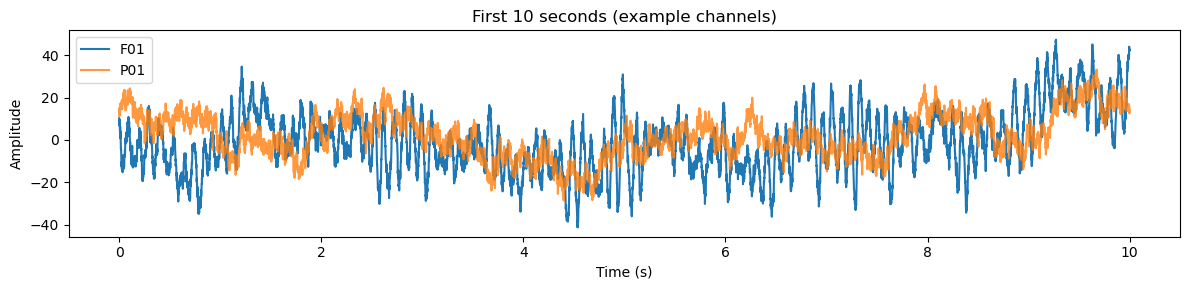

In [6]:
# Quick sanity check: plot a short segment
plt.figure(figsize=(12, 3))
sec = 10
n = int(sec * fs)
plt.plot(np.arange(n) / fs, X[:n, frontal_idx_example], label=ch_names[frontal_idx_example])
plt.plot(np.arange(n) / fs, X[:n, posterior_idx_example], label=ch_names[posterior_idx_example], alpha=0.8)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("First 10 seconds (example channels)")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# ----------------------------
# Save to MAT, then load back
# ----------------------------
mat_path = "~/SL_GPsim/examples/propofol_32ch_sim.mat" #CHANGE PATH

mdict = {
    "X": X,  # (samples, channels)
    "fs": float(fs),
    "ch_names": np.array(ch_names, dtype=object),
    "regions": regions,
    "window_duration": float(window_duration),
    "step_duration": float(window_duration),  # non-overlap
    "n_windows": int(n_windows),
    "phase_times_sec": np.array([T0, T1, T2, T3], dtype=float),
    "example": {
        "frontal_idx": int(frontal_idx_example),
        "posterior_idx": int(posterior_idx_example),
        "window_centers": window_centers,
        "params_frontal": params_example["frontal"],
        "params_posterior": params_example["posterior"],
    },
}

savemat(mat_path, mdict, do_compression=True)
print("Saved:", mat_path)

mat = loadmat(mat_path, squeeze_me=True, struct_as_record=False)
X2 = mat["X"]
fs2 = float(mat["fs"])
print("Loaded X2:", X2.shape, "fs2:", fs2)


Saved: /Users/patrick_bloniasz/SL_GPsim/examples/propofol_32ch_sim.mat
Loaded X2: (360000, 32) fs2: 1000.0


In [11]:
# ----------------------------
# Analysis helpers
# ----------------------------

def window_segments(x_1d, n_window):
    n_total = len(x_1d)
    n_windows = n_total // n_window
    return x_1d[: n_windows * n_window].reshape(n_windows, n_window)


def multitaper_spectrogram(windowed, fs, n_fft, TW=2, K=3):
    S_list = []
    f_emp = None
    for w in windowed:
        sig = w[:, None, None]
        m = Multitaper(
            time_series=sig,
            sampling_frequency=fs,
            time_halfbandwidth_product=TW,
            n_tapers=K,
            n_fft_samples=n_fft,
        )
        c = Connectivity.from_multitaper(m)
        p = c.power().squeeze()
        if p.ndim != 1:
            p = p.reshape(-1)
        if f_emp is None:
            f_emp = c.frequencies.copy()
        S_list.append(p)
    return f_emp, np.asarray(S_list)


def theoretical_spectrogram(params, fs, n_fft, f_target):
    n_windows = len(params["exponent"])

    tmp = ParametricDecomposition(
        sampling_rate=fs,
        n_fft=n_fft,
        aperiodic_exponent=1.0,
        aperiodic_offset=offset0,
        knee=None,
        peaks=[],
    ).compute()
    f = tmp.frequencies
    pos = f >= 0
    f_pos = f[pos]

    S_comb = np.zeros((n_windows, len(f_target)))
    S_bb = np.zeros((n_windows, len(f_target)))
    S_rh = np.zeros((n_windows, len(f_target)))

    for i in range(n_windows):
        expo = float(params["exponent"][i])
        alpha_amp = float(params["alpha_amp"][i])
        slow_amp = float(params["slow_amp"][i])

        peaks = []
        if alpha_amp > 1e-9:
            peaks.append({"freq": alpha_f, "amplitude": alpha_amp, "sigma": alpha_sigma})
        if slow_amp > 1e-9:
            peaks.append({"freq": slow_f, "amplitude": slow_amp, "sigma": slow_sigma})

        fd = ParametricDecomposition(
            sampling_rate=fs,
            n_fft=n_fft,
            aperiodic_exponent=expo,
            aperiodic_offset=offset0,
            knee=None,
            peaks=peaks,
        ).compute()

        comb = fd.combined_spectrum[pos]
        bb = fd.broadband_spectrum[pos]
        rh = fd.rhythmic_spectrum[pos]

        S_comb[i] = np.interp(f_target, f_pos, comb)
        S_bb[i] = np.interp(f_target, f_pos, bb)
        S_rh[i] = np.interp(f_target, f_pos, rh)

    return S_comb, S_bb, S_rh


def safe_log10(A):
    A = np.asarray(A, dtype=float)
    B = np.full_like(A, np.nan, dtype=float)
    m = A > 0
    B[m] = np.log10(A[m])
    return B


def plot_spec_linear_freq(L, t_win, f, title, fmin=0.5, fmax=40.0):
    fmask = (f >= fmin) & (f <= fmax)
    Z = L[:, fmask].T
    plt.figure(figsize=(11, 4.2))
    plt.imshow(
        Z,
        aspect="auto",
        origin="lower",
        extent=[t_win[0], t_win[-1], f[fmask][0], f[fmask][-1]],
    )
    plt.xlabel("Window center time (s)")
    plt.ylabel("Frequency (Hz)")
    plt.title(title)
    plt.colorbar(label="log10 power")
    plt.tight_layout()


def plot_grid_overlays(f, S_theo, S_bb, S_rh, S_emp, t_win, title_prefix, fmin=1.0, fmax=200.0, ymin=1e-8):
    fmask = (f >= fmin) & (f <= fmax)
    n_show = 9
    idx_show = np.linspace(0, len(t_win) - 1, n_show, dtype=int)

    ncols = 3
    nrows = int(np.ceil(n_show / ncols))

    plt.figure(figsize=(14, 10))
    for j, wi in enumerate(idx_show):
        ax = plt.subplot(nrows, ncols, j + 1)

        ff = f[fmask]
        gt_c = S_theo[wi, fmask]
        gt_bb = S_bb[wi, fmask]
        gt_rh = S_rh[wi, fmask]
        emp = S_emp[wi, fmask]

        def ok(y):
            return np.isfinite(y) & (y > 0)

        mc = ok(gt_c) & ok(emp)
        mbb = ok(gt_bb)
        mrh = ok(gt_rh)

        ax.loglog(ff[mc], gt_c[mc], label="GT combined")
        ax.loglog(ff[mc], emp[mc], label="Emp MT")
        if np.any(mbb):
            ax.loglog(ff[mbb], gt_bb[mbb], linestyle="--", label="GT bb")
        if np.any(mrh):
            ax.loglog(ff[mrh], gt_rh[mrh], linestyle="--", label="GT rh")

        ax.set_title(f"{title_prefix}: t={t_win[wi]:.1f}s (win {wi})")
        ax.set_xlabel("Hz")
        ax.set_ylabel("Power")
        ax.set_xlim(fmin, fmax)

        y_all = np.concatenate([
            gt_c[mc], emp[mc],
            gt_bb[mbb] if np.any(mbb) else np.array([]),
            gt_rh[mrh] if np.any(mrh) else np.array([]),
        ])
        ymax = (np.max(y_all) * 1.2) if y_all.size else 1.0
        ax.set_ylim(ymin, ymax)

        if j == 0:
            ax.legend(fontsize=8, loc="best")

    plt.tight_layout()


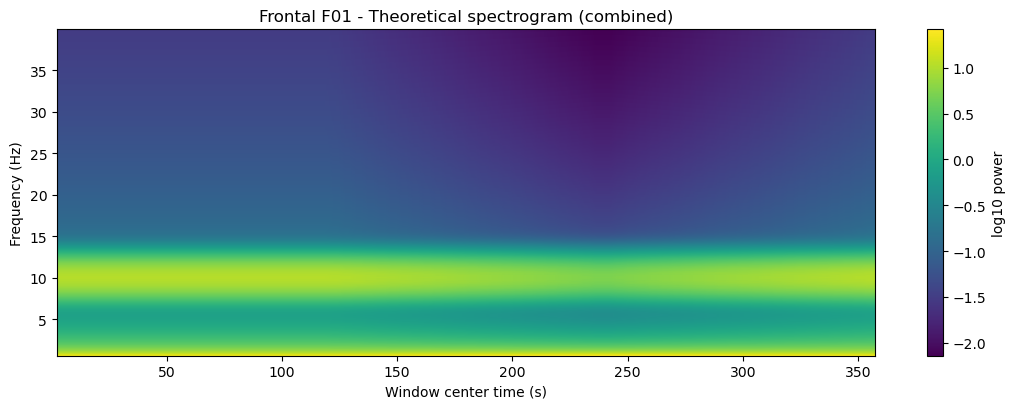

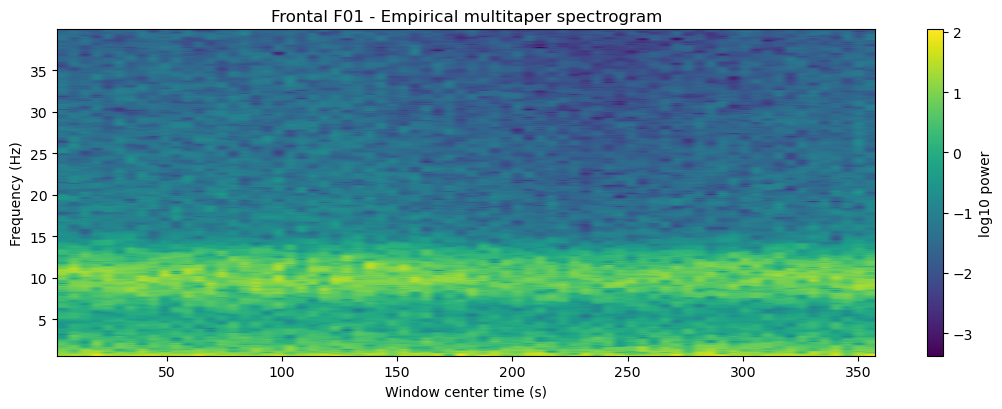

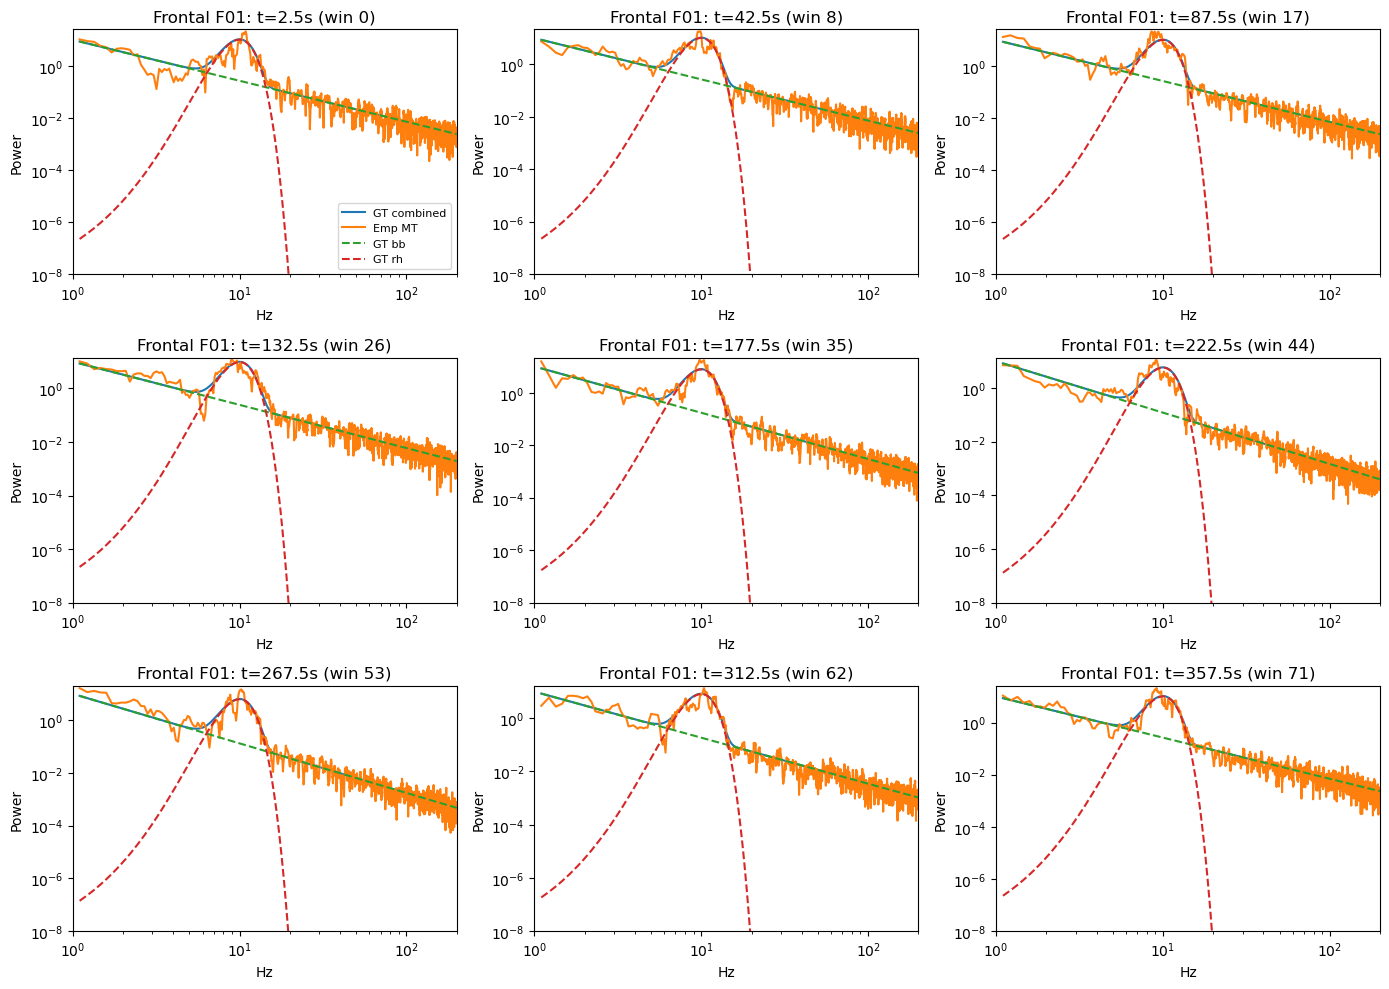

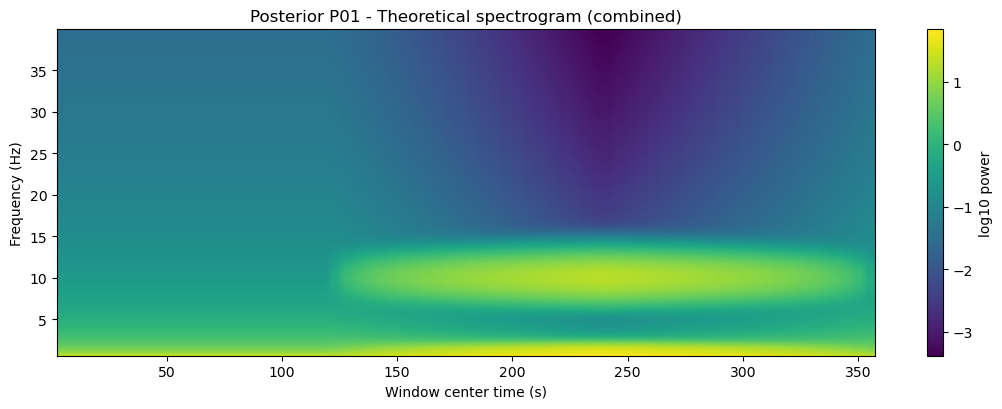

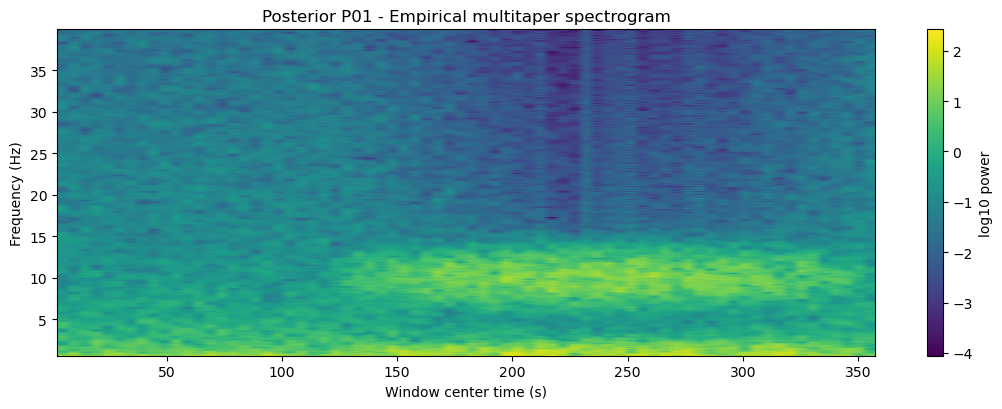

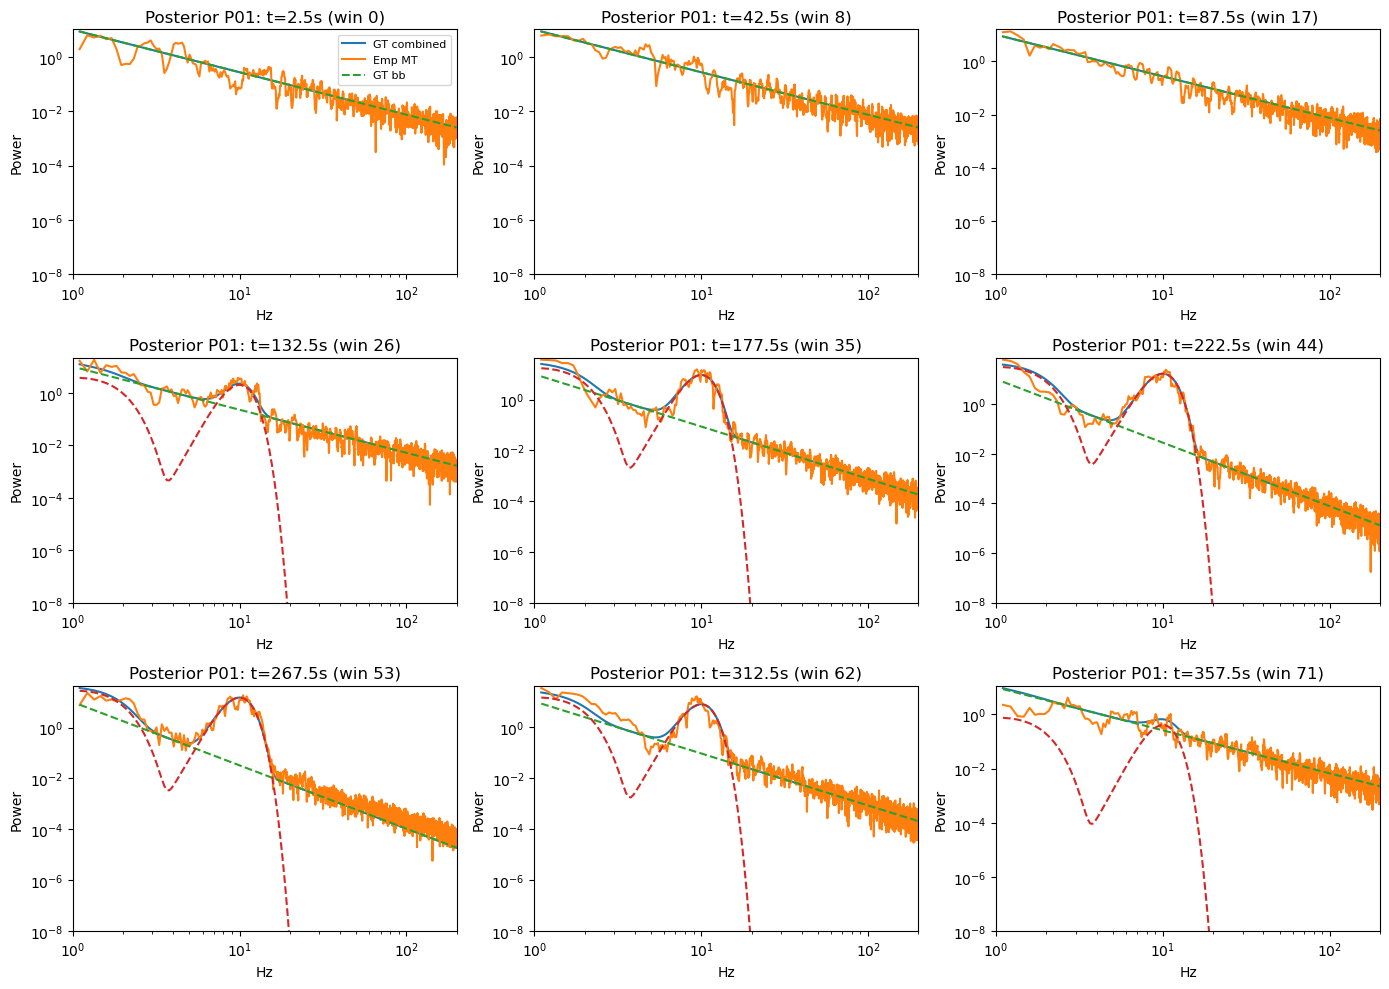

In [12]:
# ----------------------------
# Run analysis for one frontal + one posterior channel
# ----------------------------
t_win = window_centers

TW = 2
K = 3
n_fft_mt = 2 ** int(np.ceil(np.log2(n_window)))


def analyze_channel(x_1d, params, title_prefix):
    windowed = window_segments(x_1d, n_window)
    f_emp, S_emp = multitaper_spectrogram(windowed, fs2, n_fft_mt, TW=TW, K=K)

    S_theo, S_bb, S_rh = theoretical_spectrogram(params, fs2, n_fft_mt, f_emp)

    L_emp = safe_log10(S_emp)
    L_theo = safe_log10(S_theo)

    plot_spec_linear_freq(L_theo, t_win, f_emp, f"{title_prefix} - Theoretical spectrogram (combined)")
    plot_spec_linear_freq(L_emp, t_win, f_emp, f"{title_prefix} - Empirical multitaper spectrogram")

    plot_grid_overlays(f_emp, S_theo, S_bb, S_rh, S_emp, t_win, title_prefix)


x_front = X2[:, frontal_idx_example]
x_post = X2[:, posterior_idx_example]

ex = mat["example"]
params_front = {
    "exponent": np.asarray(ex.params_frontal.exponent, dtype=float),
    "alpha_amp": np.asarray(ex.params_frontal.alpha_amp, dtype=float),
    "slow_amp": np.asarray(ex.params_frontal.slow_amp, dtype=float),
}
params_post = {
    "exponent": np.asarray(ex.params_posterior.exponent, dtype=float),
    "alpha_amp": np.asarray(ex.params_posterior.alpha_amp, dtype=float),
    "slow_amp": np.asarray(ex.params_posterior.slow_amp, dtype=float),
}

analyze_channel(x_front, params_front, f"Frontal {ch_names[frontal_idx_example]}")
analyze_channel(x_post, params_post, f"Posterior {ch_names[posterior_idx_example]}")

plt.show()
